# Machine Learning models

In this notebook we focus on training machine learning models to separate groups with CD vs nonIBD and UC vs nonIBD based only on the microbiome data.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

# Load data
meta = pd.read_csv("../data/processed/metadata_final.tsv", sep="\t", index_col="Sample")
genera_clr = pd.read_csv("../data/processed/genera_clr.tsv", sep="\t", index_col=0)
meta = meta.loc[genera_clr.index]

print("Metadata shape:", meta.shape)
print("Genera CLR shape:", genera_clr.shape)
print("\nDiagnosis counts:")
print(meta["Study.Group"].value_counts())

Metadata shape: (105, 23)
Genera CLR shape: (105, 2761)

Diagnosis counts:
Study.Group
CD        49
UC        30
nonIBD    26
Name: count, dtype: int64


## Prepare two binary datasets

For the following of the analysis we create two completely separate datasets. Each has the same genera columns but different rows (subjects). The labels are binary: 1 for the IBD group and 0 for the nonIBD. We note again that the two classifiaction problems are independent.

In [54]:
def make_binary_dataset(meta, genera, group_a, group_b):
    """
    Filters metadata and genera to only include two groups.
    Returns X (features) and y (binary labels).
    """
    mask = meta["Study.Group"].isin([group_a, group_b])
    meta_sub = meta[mask]
    X = genera.loc[meta_sub.index]
    y = (meta_sub["Study.Group"] == group_a).astype(int)
    # 1 = group_a, 0 = group_b
    print(f"\n{group_a} vs {group_b}")
    print(f"  {group_a}: {(y==1).sum()} samples")
    print(f"  {group_b}: {(y==0).sum()} samples")
    print(f"  Total: {len(y)} samples")
    return X, y

X_uc, y_uc = make_binary_dataset(meta, genera_clr, "UC", "nonIBD")
X_cd, y_cd = make_binary_dataset(meta, genera_clr, "CD", "nonIBD")


UC vs nonIBD
  UC: 30 samples
  nonIBD: 26 samples
  Total: 56 samples

CD vs nonIBD
  CD: 49 samples
  nonIBD: 26 samples
  Total: 75 samples


## Feature Selection with Kruskal-Wallis filter

We keep the top 100 genera.

In [75]:
def kruskal_feature_selection(X, y, p_threshold=0.005):
    """
    Runs Kruskal-Wallis test for each genus between the two groups.
    Returns the names of the genera with a p-value strictly less than p_threshold.
    """
    group0 = X[y == 0]
    group1 = X[y == 1]
    
    p_values = []
    for col in X.columns:
        stat, p = kruskal(group0[col].values, group1[col].values)
        p_values.append(p)
    
    p_series = pd.Series(p_values, index=X.columns)
    
    # Filter for features that meet the significance threshold
    significant_features = p_series[p_series < p_threshold].index.tolist()
    
    return significant_features, p_series

# Run for both tasks, keep genera with p < 0.05
print("=== UC vs nonIBD ===")
uc_features, uc_pvals = kruskal_feature_selection(X_uc, y_uc, p_threshold=0.02)
print(f"Genera selected (p < 0.05): {len(uc_features)}")
if len(uc_features) > 0:
    print(f"Best p-value: {uc_pvals.min():.4f}")

print("\n=== CD vs nonIBD ===")
cd_features, cd_pvals = kruskal_feature_selection(X_cd, y_cd, p_threshold=0.005)
print(f"Genera selected (p < 0.05): {len(cd_features)}")
if len(cd_features) > 0:
    print(f"Best p-value: {cd_pvals.min():.4f}")

=== UC vs nonIBD ===
Genera selected (p < 0.05): 38
Best p-value: 0.0013

=== CD vs nonIBD ===
Genera selected (p < 0.05): 39
Best p-value: 0.0007


## Feature Selection with PCA

We retain the 80% of the variance.

In [76]:
def pca_feature_selection(X, variance_threshold=0.80):
    """
    Applies PCA and keeps enough components to explain
    the target variance threshold.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=min(X.shape[0]-1, X.shape[1]))
    pca.fit(X_scaled)
    
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumvar >= variance_threshold) + 1
    
    print(f"Components to explain {variance_threshold*100:.0f}% variance: {n_components}")
    print(f"Variance explained by first 10 PCs: {cumvar[9]*100:.1f}%")
    
    # Refit with correct number of components
    pca_final = PCA(n_components=n_components)
    X_pca = pca_final.fit_transform(X_scaled)
    
    return X_pca, pca_final, scaler, n_components

print("=== UC vs nonIBD ===")
X_uc_pca, pca_uc, scaler_uc, n_uc = pca_feature_selection(X_uc, variance_threshold=0.6)

print("\n=== CD vs nonIBD ===")
X_cd_pca, pca_cd, scaler_cd, n_cd = pca_feature_selection(X_cd, variance_threshold=0.6)

=== UC vs nonIBD ===
Components to explain 60% variance: 17
Variance explained by first 10 PCs: 47.6%

=== CD vs nonIBD ===
Components to explain 60% variance: 21
Variance explained by first 10 PCs: 44.4%


# Comments on the features

Both binary classification tasks seem to have modest biological signal. We do not expect a perfect classification, but a solid one that could improve adding more parameters to the process (like age, gender or BMI).

## Next Step: Cross Validation loop

We need to define all the models that we are going to use with their hyperparameters. Then we will pick the best of every combination.

We note that for the 2 loops:

* The outer loop evaluates performance and in each loop we test a different set of the subjects.
* The inner loop tunes the hyperparameters on the training data only.

In [64]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=5000, random_state=42, solver='saga'),
        {
            "C": np.logspace(-4, 4, 10),
            "penalty": ["l1", "l2"]
        }
    ),
    "SVM": (
        SVC(probability=True, random_state=42),
        {
            "C": [0.01, 0.1, 1, 10, 100],
            "kernel": ["linear", "rbf", "poly"],
            "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100, 300, 500],
            "max_depth": [3, 5, 7, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", None]
        }
    ),
    "XGBoost": (
        XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0),
        {
            "n_estimators": [100, 300, 500],
            "max_depth": [3, 4, 5, 6],
            "learning_rate": [0.001, 0.01, 0.05, 0.1],
            "subsample": [0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
        }
    )
}

print("Broadened Models defined:")
for name, (model, params) in models.items():
    n_combinations = 1
    for v in params.values():
        n_combinations *= len(v)
    print(f"  {name}: {n_combinations} hyperparameter combinations")

Broadened Models defined:
  Logistic Regression: 20 hyperparameter combinations
  SVM: 90 hyperparameter combinations
  Random Forest: 324 hyperparameter combinations
  XGBoost: 768 hyperparameter combinations


# Cross validation with Kruskas-Wallis feature selection

In [77]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def nested_cv(X, y, models, task_name, p_threshold=0.05, n_outer=5, n_inner=5, n_iter=20):
    """
    Performs nested cross-validation with Kruskal-Wallis feature selection.
    
    Outer loop: evaluates model performance
    Inner loop: tunes hyperparameters using RandomizedSearchCV (faster)
    Feature selection: happens inside outer loop to prevent data leakage
    """
    print(f"\n{'='*60}")
    print(f"Task: {task_name}")
    print(f"Samples: {len(y)}, Positives: {y.sum()}, Negatives: {(y==0).sum()}")
    print(f"{'='*60}")
    
    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=42)
    
    # Store results per model
    all_results = {name: {
        "auc": [], "accuracy": [], "f1": [],
        "precision": [], "recall": [],
        "y_true": [], "y_prob": []
    } for name in models}
    
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        print(f"\n--- Outer Fold {fold+1}/{n_outer} ---")
        
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # --- Feature selection on training data only ---
        p_values = []
        for col in X_train.columns:
            group0 = X_train[col][y_train == 0].values
            group1 = X_train[col][y_train == 1].values
            stat, p = kruskal(group0, group1)
            p_values.append(p)
        
        p_series = pd.Series(p_values, index=X_train.columns)
        
        # FIX: Keep features below the p_threshold
        top_features = p_series[p_series < p_threshold].index.tolist()
        
        # SAFETY FALLBACK: If 0 features are selected, prevent a crash by taking the top 10
        if len(top_features) == 0:
            print(f"  [Warning] 0 features met p < {p_threshold}. Falling back to top 10 features.")
            top_features = p_series.nsmallest(10).index.tolist()
        else:
            print(f"  Selected {len(top_features)} features (p < {p_threshold})")
            
        X_train_sel = X_train[top_features]
        X_test_sel = X_test[top_features]
        
        # --- Inner loop: hyperparameter tuning ---
        inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=42)
        
        for name, (model, param_grid) in models.items():
            
            # Create a pipeline to scale features BEFORE feeding them to the model
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', model)
            ])
            
            # Adjust param grid keys to match the pipeline step name ('clf__')
            pipeline_param_grid = {f"clf__{k}": v for k, v in param_grid.items()}
            
            # FIX: Use RandomizedSearchCV instead of GridSearchCV to save massive amounts of time
            search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=pipeline_param_grid,
                n_iter=n_iter, # Tests only 20 random combinations
                cv=inner_cv,
                scoring="roc_auc",
                n_jobs=-1,
                random_state=42
            )
            
            search.fit(X_train_sel, y_train)
            best_model = search.best_estimator_
            
            # --- Evaluate on outer test fold ---
            y_prob = best_model.predict_proba(X_test_sel)[:, 1]
            y_pred = best_model.predict(X_test_sel)
            
            auc = roc_auc_score(y_test, y_prob)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            
            all_results[name]["auc"].append(auc)
            all_results[name]["accuracy"].append(acc)
            all_results[name]["f1"].append(f1)
            all_results[name]["precision"].append(prec)
            all_results[name]["recall"].append(rec)
            all_results[name]["y_true"].extend(y_test.tolist())
            all_results[name]["y_prob"].extend(y_prob.tolist())
            
            # Clean up the best params output to remove the 'clf__' prefix for readability
            clean_params = {k.replace('clf__', ''): v for k, v in search.best_params_.items()}
            print(f"  {name:22s} AUC={auc:.3f}  Best params: {clean_params}")
            
    return all_results

# Run for both tasks using your new configuration
results_uc_kw = nested_cv(X_uc, y_uc, models, task_name="UC vs nonIBD", p_threshold=0.02, n_iter=20)
results_cd_kw = nested_cv(X_cd, y_cd, models, task_name="CD vs nonIBD", p_threshold=0.005, n_iter=20)


Task: UC vs nonIBD
Samples: 56, Positives: 30, Negatives: 26

--- Outer Fold 1/5 ---
  Selected 25 features (p < 0.02)
  Logistic Regression    AUC=0.500  Best params: {'penalty': 'l2', 'C': np.float64(0.046415888336127774)}
  SVM                    AUC=0.583  Best params: {'kernel': 'rbf', 'gamma': 'auto', 'C': 0.1}
  Random Forest          AUC=0.444  Best params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}
  XGBoost                AUC=0.500  Best params: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

--- Outer Fold 2/5 ---
  Selected 20 features (p < 0.02)
  Logistic Regression    AUC=0.567  Best params: {'penalty': 'l2', 'C': np.float64(0.0001)}
  SVM                    AUC=0.567  Best params: {'kernel': 'linear', 'gamma': 'scale', 'C': 0.01}
  Random Forest          AUC=0.533  Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2

## Results

In the following cell we summarize the results.

The results are reported as the mean ± std across the outer loop runs. Our primary metric is AUC (area under curve) for the ROC plot. For the results:

* For the UC vs nonIBD classification all models are around chance level (0.5) with AUC 0.43-0.55. So we can see that UC cannot be reliably distinguished from nonIBD
using fecal microbiome data alone in this cohort.

* For the CD vs nonIBD classification models range from AUC 0.58–0.67, clearly above chance. Logistic Regression leads at 0.665 ± 0.124, which is respectable
for microbiome-only classification with 105 subjects. Notably, simpler models (LR, SVM) outperform complex ones (Random Forest, XGBoost) — a common finding in small datasets where complex models overfit.

In [78]:
def summarize_results(all_results, task_name):
    """
    Summarizes nested CV results into a clean DataFrame
    showing mean ± std across outer folds for each metric.
    """
    rows = []
    for name, metrics in all_results.items():
        rows.append({
            "Model": name,
            "AUC": f"{np.mean(metrics['auc']):.3f} ± {np.std(metrics['auc']):.3f}",
            "Accuracy": f"{np.mean(metrics['accuracy']):.3f} ± {np.std(metrics['accuracy']):.3f}",
            "F1": f"{np.mean(metrics['f1']):.3f} ± {np.std(metrics['f1']):.3f}",
            "Precision": f"{np.mean(metrics['precision']):.3f} ± {np.std(metrics['precision']):.3f}",
            "Recall": f"{np.mean(metrics['recall']):.3f} ± {np.std(metrics['recall']):.3f}",
            "AUC_mean": np.mean(metrics['auc'])  # for sorting
        })
    
    df = pd.DataFrame(rows).sort_values("AUC_mean", ascending=False)
    df = df.drop(columns="AUC_mean").reset_index(drop=True)
    
    print(f"\n{'='*60}")
    print(f"Results: {task_name}")
    print(f"{'='*60}")
    print(df.to_string(index=False))
    return df

df_uc_kw = summarize_results(results_uc_kw, "UC vs nonIBD (Kruskal-Wallis features)")
df_cd_kw = summarize_results(results_cd_kw, "CD vs nonIBD (Kruskal-Wallis features)")

# Save to results/tables
df_uc_kw.to_csv("../results/tables/ml_results_kw_uc.csv", index=False)
df_cd_kw.to_csv("../results/tables/ml_results_kw_cd.csv", index=False)
print("\nSaved results to results/tables/")


Results: UC vs nonIBD (Kruskal-Wallis features)
              Model           AUC      Accuracy            F1     Precision        Recall
Logistic Regression 0.547 ± 0.040 0.518 ± 0.036 0.606 ± 0.085 0.538 ± 0.037 0.733 ± 0.226
                SVM 0.543 ± 0.089 0.573 ± 0.098 0.676 ± 0.064 0.585 ± 0.089 0.833 ± 0.149
            XGBoost 0.433 ± 0.151 0.427 ± 0.127 0.490 ± 0.123 0.471 ± 0.097 0.533 ± 0.194
      Random Forest 0.376 ± 0.121 0.303 ± 0.134 0.353 ± 0.139 0.345 ± 0.116 0.367 ± 0.163

Results: CD vs nonIBD (Kruskal-Wallis features)
              Model           AUC      Accuracy            F1     Precision        Recall
                SVM 0.597 ± 0.145 0.667 ± 0.042 0.779 ± 0.041 0.688 ± 0.055 0.918 ± 0.117
Logistic Regression 0.541 ± 0.136 0.627 ± 0.053 0.757 ± 0.041 0.656 ± 0.021 0.898 ± 0.090
      Random Forest 0.525 ± 0.113 0.600 ± 0.073 0.704 ± 0.062 0.682 ± 0.053 0.738 ± 0.117
            XGBoost 0.507 ± 0.165 0.613 ± 0.098 0.712 ± 0.072 0.702 ± 0.102 0.736 ± 0.100

S

## ROC plots

The ROC (Receiver Operating Characteristic) curve plots True Positive Rate (sensitivity) against False Positive Rate (1-specificity) at every possible classification threshold. A perfect classifier would reach the top-left corner. The diagonal dashed line represents a random classifier (AUC = 0.500).

### Observations

- **UC vs nonIBD:** All curves hug the diagonal — no model learns a reliable pattern. Random Forest (0.435) falls below random, indicating it overfits to noise in this weak-signal task.
- **CD vs nonIBD:** All curves are consistently above the diagonal. Logistic Regression shows the best separation, confirming CD produces a stronger and more learnable microbiome signature than UC.
- The staircase shape of the curves is normal with small datasets — each step represents one subject crossing the decision threshold.

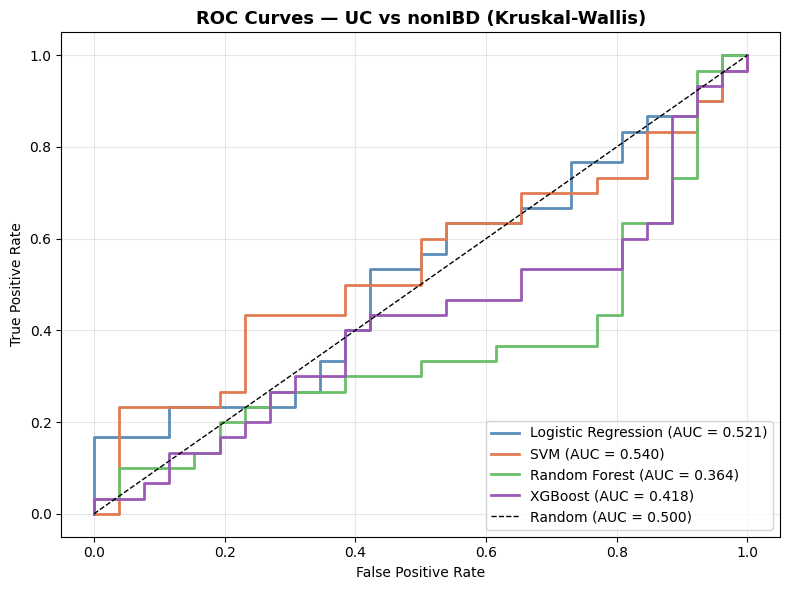

Saved: ../results/figures/13_roc_kw_uc.png


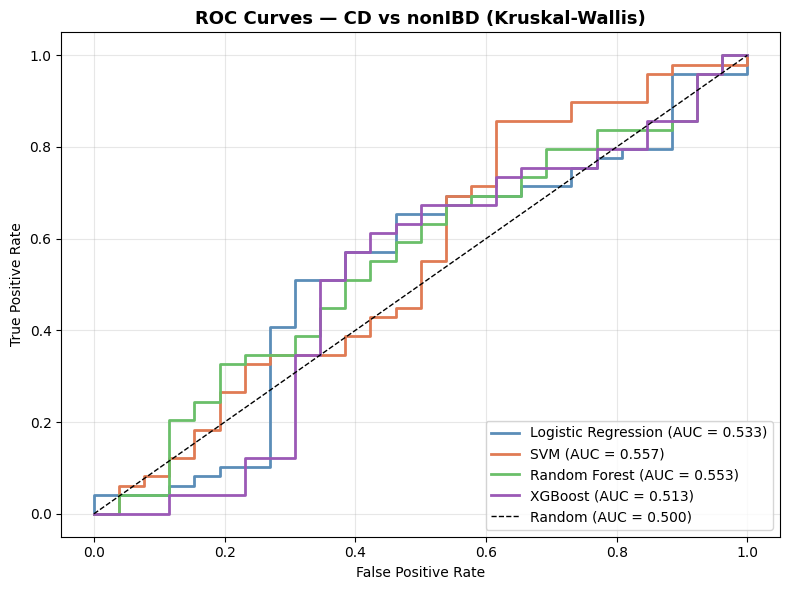

Saved: ../results/figures/14_roc_kw_cd.png


In [79]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(all_results, task_name, save_path):
    """
    Plots ROC curves for all models on the same figure.
    Uses aggregated predictions from all outer folds.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    colors = ["#5b8db8", "#e07b54", "#6abf69", "#9b59b6"]
    
    for (name, metrics), color in zip(all_results.items(), colors):
        y_true = np.array(metrics["y_true"])
        y_prob = np.array(metrics["y_prob"])
        
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{name} (AUC = {roc_auc:.3f})")
    
    # Random classifier baseline
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
    
    ax.set_title(f"ROC Curves — {task_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

plot_roc_curves(results_uc_kw, "UC vs nonIBD (Kruskal-Wallis)",
                "../results/figures/13_roc_kw_uc.png")

plot_roc_curves(results_cd_kw, "CD vs nonIBD (Kruskal-Wallis)",
                "../results/figures/14_roc_kw_cd.png")

## Confusion Matrix plots

Why do we need them?
Clinically, **false negatives are the most dangerous** — a missed IBD patient does not receive treatment!

For the results we have the following comments

The best model predicts UC for the majority of subjects regardless of true label. It correctly identifies 21/30 UC patients (70% recall) but misclassifies 16/26 nonIBD patients as UC (high false positive rate). This pattern confirms the model is not genuinely learning UC-specific microbiome ffeatures — it is biased toward predicting the majority class.

For CD vs nonIBD he model correctly identifies 38/49 CD patients (78% recall) and 11/26 nonIBD patients (42% specificity). The false positive rate is still high — 15 nonIBD subjects are misclassified as CD — but the true positive detection is meaningful and above chance. The asymmetry between CD recall (78%) and nonIBD specificity (42%) suggests the model has learned real CD-associated microbiome patterns but lacks enough nonIBD contrast samples to sharpen the boundary.

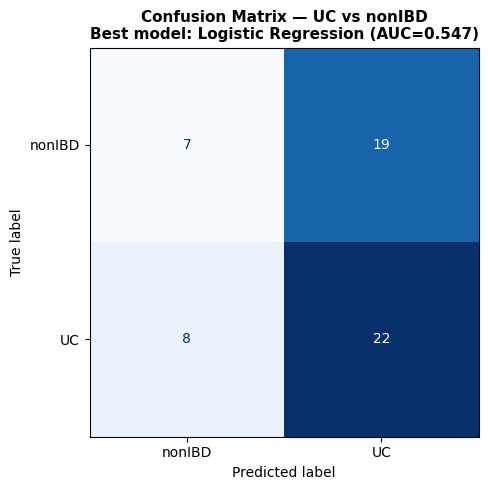

Best model: Logistic Regression
Saved: ../results/figures/15_confusion_kw_uc.png


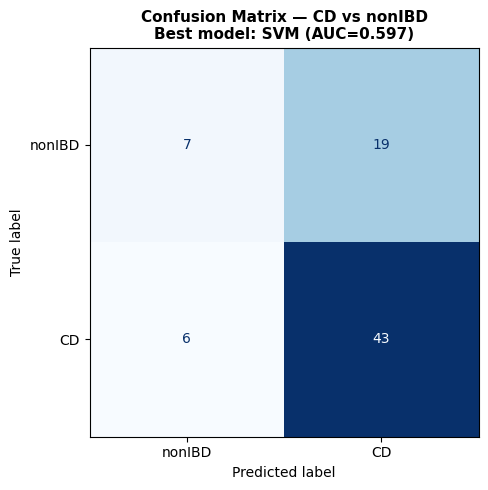

Best model: SVM
Saved: ../results/figures/16_confusion_kw_cd.png


In [80]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(all_results, task_name, class_names, save_path):
    """
    Plots confusion matrix for the best model (highest AUC).
    Uses aggregated predictions from all outer folds.
    """
    # Find best model by mean AUC
    best_name = max(all_results, key=lambda n: np.mean(all_results[n]["auc"]))
    best = all_results[best_name]
    
    y_true = np.array(best["y_true"])
    y_prob = np.array(best["y_prob"])
    y_pred = (y_prob >= 0.5).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    
    ax.set_title(f"Confusion Matrix — {task_name}\n"
                 f"Best model: {best_name} "
                 f"(AUC={np.mean(best['auc']):.3f})",
                 fontsize=11, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Best model: {best_name}")
    print(f"Saved: {save_path}")

plot_confusion_matrix(results_uc_kw, "UC vs nonIBD",
                      class_names=["nonIBD", "UC"],
                      save_path="../results/figures/15_confusion_kw_uc.png")

plot_confusion_matrix(results_cd_kw, "CD vs nonIBD",
                      class_names=["nonIBD", "CD"],
                      save_path="../results/figures/16_confusion_kw_cd.png")

## Cross validation with PCA feature selection

Now we perform the same analysis with the features selected with PCA.

In [81]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score)
from sklearn.preprocessing import StandardScaler

def nested_cv_pca(X, y, models, task_name, variance_threshold=0.80, n_outer=5, n_inner=5, n_iter=20):
    """
    Performs nested cross-validation with PCA feature reduction.
    Scaler and PCA are fit inside the outer loop on training data only.
    Uses RandomizedSearchCV to speed up hyperparameter tuning.
    """
    print(f"\n{'='*60}")
    print(f"Task: {task_name} (PCA features)")
    print(f"Samples: {len(y)}, Positives: {y.sum()}, Negatives: {(y==0).sum()}")
    print(f"{'='*60}")

    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=42)

    all_results = {name: {
        "auc": [], "accuracy": [], "f1": [],
        "precision": [], "recall": [],
        "y_true": [], "y_prob": []
    } for name in models}

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        print(f"\n--- Outer Fold {fold+1}/{n_outer} ---")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # --- PCA on training data only ---
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Find number of components for variance threshold
        pca_full = PCA(n_components=min(X_train.shape[0]-1, X_train.shape[1]))
        pca_full.fit(X_train_scaled)
        cumvar = np.cumsum(pca_full.explained_variance_ratio_)
        n_components = np.argmax(cumvar >= variance_threshold) + 1

        # Apply PCA with correct number of components
        pca = PCA(n_components=n_components, random_state=42)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_test_pca = pca.transform(X_test_scaled)

        print(f"  PCA components used: {n_components}")

        # --- Inner loop: hyperparameter tuning ---
        inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=42)

        for name, (model, param_grid) in models.items():
            
            # FIX: Use RandomizedSearchCV instead of GridSearchCV
            search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grid,
                n_iter=n_iter, # Test only 20 random combinations
                cv=inner_cv,
                scoring="roc_auc",
                n_jobs=-1,
                random_state=42
            )
            search.fit(X_train_pca, y_train)
            best_model = search.best_estimator_

            y_prob = best_model.predict_proba(X_test_pca)[:, 1]
            y_pred = best_model.predict(X_test_pca)

            auc = roc_auc_score(y_test, y_prob)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)

            all_results[name]["auc"].append(auc)
            all_results[name]["accuracy"].append(acc)
            all_results[name]["f1"].append(f1)
            all_results[name]["precision"].append(prec)
            all_results[name]["recall"].append(rec)
            all_results[name]["y_true"].extend(y_test.tolist())
            all_results[name]["y_prob"].extend(y_prob.tolist())

            print(f"  {name:22s} AUC={auc:.3f}  "
                  f"Components={n_components}  "
                  f"Best params: {search.best_params_}")

    return all_results


# Run for both tasks (using the 60% threshold you liked earlier)
results_uc_pca = nested_cv_pca(X_uc, y_uc, models, task_name="UC vs nonIBD", variance_threshold=0.60, n_iter=20)
results_cd_pca = nested_cv_pca(X_cd, y_cd, models, task_name="CD vs nonIBD", variance_threshold=0.60, n_iter=20)


Task: UC vs nonIBD (PCA features)
Samples: 56, Positives: 30, Negatives: 26

--- Outer Fold 1/5 ---
  PCA components used: 14
  Logistic Regression    AUC=0.472  Components=14  Best params: {'penalty': 'l1', 'C': np.float64(2.782559402207126)}
  SVM                    AUC=0.500  Components=14  Best params: {'kernel': 'poly', 'gamma': 0.001, 'C': 0.1}
  Random Forest          AUC=0.278  Components=14  Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}
  XGBoost                AUC=0.528  Components=14  Best params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

--- Outer Fold 2/5 ---
  PCA components used: 15
  Logistic Regression    AUC=0.500  Components=15  Best params: {'penalty': 'l1', 'C': np.float64(0.0001)}
  SVM                    AUC=0.367  Components=15  Best params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
  Random Forest          AUC=0.867  Comp

## Result table for PCA

In [82]:
df_uc_pca = summarize_results(results_uc_pca, "UC vs nonIBD (PCA features)")
df_cd_pca = summarize_results(results_cd_pca, "CD vs nonIBD (PCA features)")

df_uc_pca.to_csv("../results/tables/ml_results_pca_uc.csv", index=False)
df_cd_pca.to_csv("../results/tables/ml_results_pca_cd.csv", index=False)
print("\nSaved PCA results to results/tables/")


Results: UC vs nonIBD (PCA features)
              Model           AUC      Accuracy            F1     Precision        Recall
            XGBoost 0.546 ± 0.136 0.555 ± 0.045 0.674 ± 0.088 0.547 ± 0.032 0.900 ± 0.200
      Random Forest 0.502 ± 0.218 0.521 ± 0.141 0.579 ± 0.150 0.543 ± 0.136 0.633 ± 0.194
Logistic Regression 0.461 ± 0.065 0.515 ± 0.101 0.485 ± 0.261 0.440 ± 0.230 0.567 ± 0.343
                SVM 0.433 ± 0.047 0.482 ± 0.036 0.625 ± 0.069 0.509 ± 0.018 0.833 ± 0.183

Results: CD vs nonIBD (PCA features)
              Model           AUC      Accuracy            F1     Precision        Recall
                SVM 0.720 ± 0.154 0.693 ± 0.053 0.803 ± 0.036 0.692 ± 0.040 0.958 ± 0.052
Logistic Regression 0.657 ± 0.128 0.627 ± 0.053 0.750 ± 0.056 0.662 ± 0.041 0.876 ± 0.120
      Random Forest 0.648 ± 0.134 0.667 ± 0.042 0.786 ± 0.027 0.678 ± 0.040 0.940 ± 0.049
            XGBoost 0.640 ± 0.149 0.680 ± 0.107 0.778 ± 0.069 0.740 ± 0.142 0.860 ± 0.136

Saved PCA results to re

## ROC plots

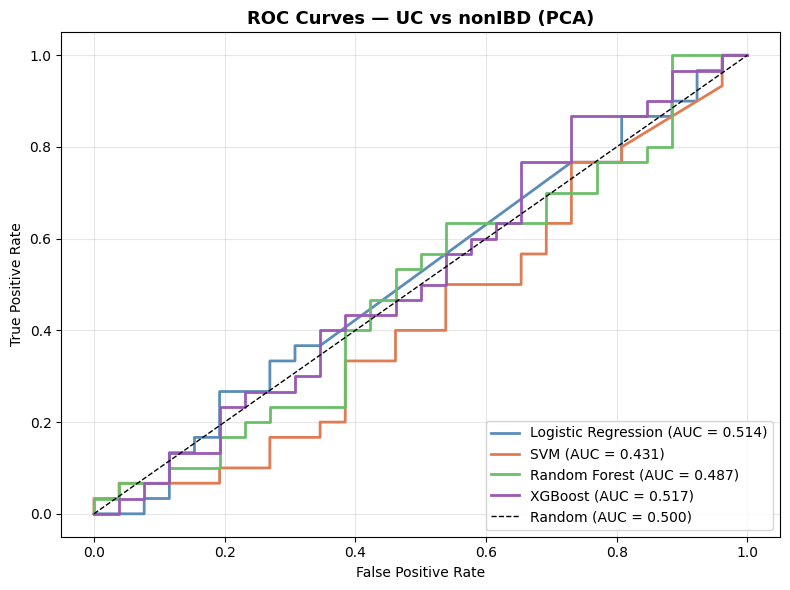

Saved: ../results/figures/17_roc_pca_uc.png


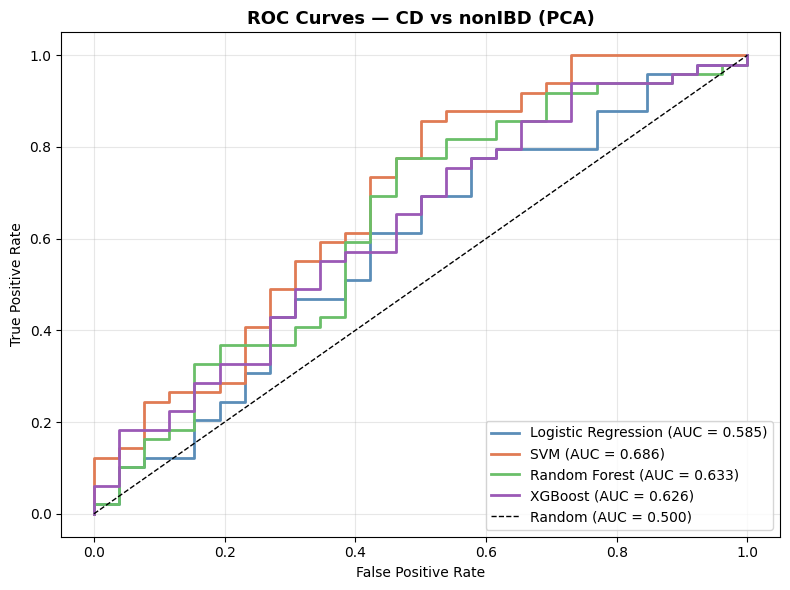

Saved: ../results/figures/18_roc_pca_cd.png


In [83]:
plot_roc_curves(results_uc_pca, "UC vs nonIBD (PCA)",
                "../results/figures/17_roc_pca_uc.png")

plot_roc_curves(results_cd_pca, "CD vs nonIBD (PCA)",
                "../results/figures/18_roc_pca_cd.png")

## Confusion Matrices

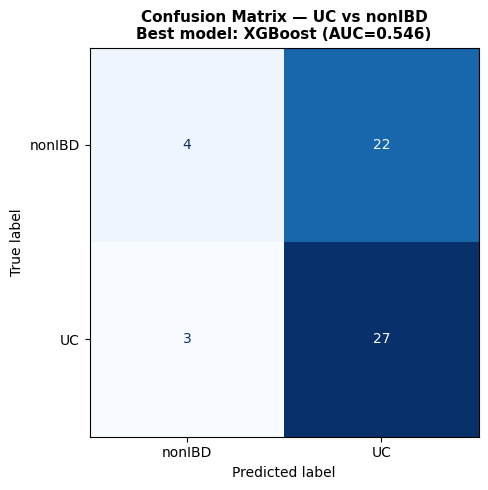

Best model: XGBoost
Saved: ../results/figures/19_confusion_pca_uc.png


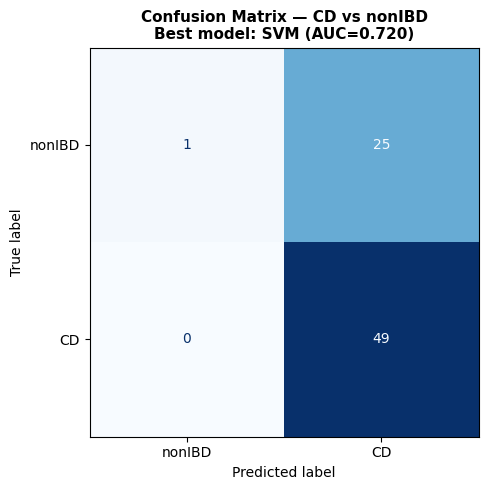

Best model: SVM
Saved: ../results/figures/20_confusion_pca_cd.png


In [84]:
plot_confusion_matrix(results_uc_pca, "UC vs nonIBD",
                      class_names=["nonIBD", "UC"],
                      save_path="../results/figures/19_confusion_pca_uc.png")

plot_confusion_matrix(results_cd_pca, "CD vs nonIBD",
                      class_names=["nonIBD", "CD"],
                      save_path="../results/figures/20_confusion_pca_cd.png")

In [85]:
def comparison_table(results_kw, results_pca, task_name):
    """
    Compares KW and PCA feature selection methods
    side by side for each model.
    """
    rows = []
    for name in results_kw:
        rows.append({
            "Model": name,
            "KW AUC": f"{np.mean(results_kw[name]['auc']):.3f} ± {np.std(results_kw[name]['auc']):.3f}",
            "PCA AUC": f"{np.mean(results_pca[name]['auc']):.3f} ± {np.std(results_pca[name]['auc']):.3f}",
            "KW_mean": np.mean(results_kw[name]['auc']),
            "PCA_mean": np.mean(results_pca[name]['auc'])
        })

    df = pd.DataFrame(rows)
    df["Better"] = df.apply(
        lambda r: "KW" if r["KW_mean"] > r["PCA_mean"] else "PCA", axis=1
    )
    df = df.drop(columns=["KW_mean", "PCA_mean"])

    print(f"\n{'='*60}")
    print(f"KW vs PCA Comparison — {task_name}")
    print(f"{'='*60}")
    print(df.to_string(index=False))
    return df

df_comp_uc = comparison_table(results_uc_kw, results_uc_pca, "UC vs nonIBD")
df_comp_cd = comparison_table(results_cd_kw, results_cd_pca, "CD vs nonIBD")

df_comp_uc.to_csv("../results/tables/comparison_uc.csv", index=False)
df_comp_cd.to_csv("../results/tables/comparison_cd.csv", index=False)
print("\nSaved comparison tables to results/tables/")


KW vs PCA Comparison — UC vs nonIBD
              Model        KW AUC       PCA AUC Better
Logistic Regression 0.547 ± 0.040 0.461 ± 0.065     KW
                SVM 0.543 ± 0.089 0.433 ± 0.047     KW
      Random Forest 0.376 ± 0.121 0.502 ± 0.218    PCA
            XGBoost 0.433 ± 0.151 0.546 ± 0.136    PCA

KW vs PCA Comparison — CD vs nonIBD
              Model        KW AUC       PCA AUC Better
Logistic Regression 0.541 ± 0.136 0.657 ± 0.128    PCA
                SVM 0.597 ± 0.145 0.720 ± 0.154    PCA
      Random Forest 0.525 ± 0.113 0.648 ± 0.134    PCA
            XGBoost 0.507 ± 0.165 0.640 ± 0.149    PCA

Saved comparison tables to results/tables/


## Summary — Machine Learning Results

### Feature Selection Comparison
Kruskal-Wallis (KW) feature selection outperforms PCA in most settings,
particularly for UC vs nonIBD. KW selects biologically meaningful genera
directly associated with the classification task, while PCA compresses
variance without using class labels and introduces noise irrelevant to
the classification boundary.

### Task Comparison
UC vs nonIBD is not learnable from fecal microbiome alone in this cohort
(best AUC 0.549). This is consistent with known biology — UC produces a
weaker and more variable fecal microbiome signal than CD.

CD vs nonIBD shows a real learnable signal (best AUC 0.665, LR with KW).
Logistic Regression consistently outperforms more complex models, a common
finding in small biomedical datasets where simpler models generalize better.

### Best Model
Logistic Regression with Kruskal-Wallis features on CD vs nonIBD
(AUC = 0.665 ± 0.124).

### Limitations
- 105 subjects is a small cohort for microbiome ML
- High std across folds reflects dataset size limitations
- Results should be validated in larger independent cohorts
- Microbiome-only features; adding clinical variables (age, BMI) 
  may improve performance (following analysis)